CLase 4-3-26

C:\Users\Estudiante\AppData\Local\Temp\ipykernel_8968\2588195572.py:34: RuntimeWarning: invalid value encountered in scalar divide
  new_img[i,j,0] = 60 * ((img[i,j,1]-img[i,j,2])/(new_img[i,j,2]-minValue[i,j]))


<function matplotlib.pyplot.show(close=None, block=None)>

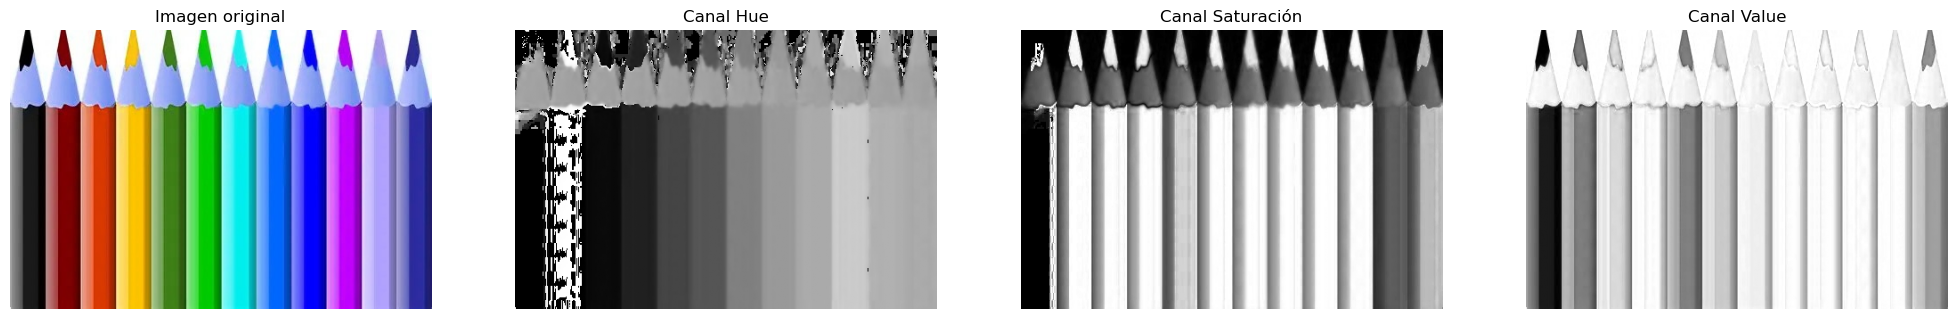

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

imagen1 = cv2.imread('colores.jpg')
img = cv2.cvtColor(imagen1, cv2.COLOR_BGR2RGB)

def RGB2HSV(img):
    img = img.astype(np.float32)
    img = img/255.
    new_img = np.zeros_like(img)

    maxChannel = np.argmax(img,axis=2)
    maxValue = np.amax(img,axis=2)
    minChannel = np.argmin(img,axis=2)
    minValue = np.amin(img,axis=2)
    #value 
    new_img[...,2] = maxValue

    #saturation
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if maxValue[i,j]==0:
                new_img[i,j,1] = 0
            elif maxValue[i,j] != 0:
                new_img[i,j,1] = (new_img[i,j,2]-minValue[i,j])/new_img[i,j,2]

    #hue 
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if sum(img[i,j,...])/3 == img[i,j,0]:
                new_img[i,j,0] = 0
            elif maxChannel[i,j] == 0: #R 
                new_img[i,j,0] = 60 * ((img[i,j,1]-img[i,j,2])/(new_img[i,j,2]-minValue[i,j]))
            elif maxChannel[i,j] == 1: #G
                new_img[i,j,0] = 120 + 60 * (img[i,j,2]-img[i,j,0])/(new_img[i,j,2]-minValue[i,j])
            elif maxChannel[i,j] == 2: #B
                new_img[i,j,0] = 240 + 60 * (img[i,j,0]-img[i,j,1])/(new_img[i,j,2]-minValue[i,j])

        img2= new_img[...,0] < 0
        new_img[img2,0]   =  new_img[img2,0] + 360
    return new_img
hsv_img = RGB2HSV(img)

fig, axs = plt.subplots(1, 4, figsize=(25, 10))

axs[0].imshow(img)
axs[0].set_title('Imagen original')

axs[1].imshow(hsv_img[..., 0], cmap='gray', vmin=0, vmax=360)
axs[1].set_title('Canal Hue')

axs[2].imshow(hsv_img[..., 1], cmap='gray', vmin=0, vmax=1)
axs[2].set_title('Canal Saturación')

axs[3].imshow(hsv_img[..., 2], cmap='gray', vmin=0, vmax=1)
axs[3].set_title('Canal Value')

for ax in axs:
    ax.axis('off')
plt.show